# Problem 1 

**a. Sketch the empirical cumulative distribution function.**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

<Axes: ylabel='Proportion'>

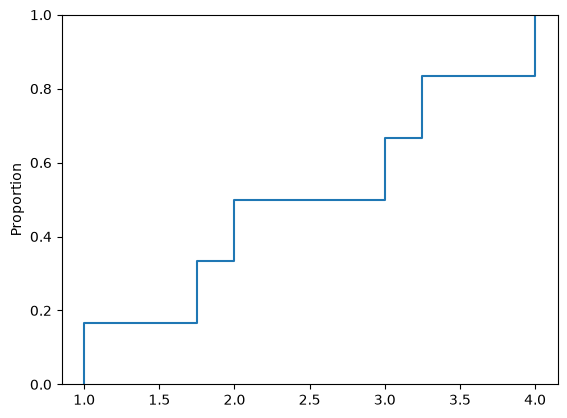

In [2]:
# [1, 1.75, 2, 3, 3.25, 4]
data = [1, 1.75, 2, 3, 3.25, 4]
sns.ecdfplot(data=data)


**Sketch the uniform kernel density estimator for a bandwidth of h = 0.2**

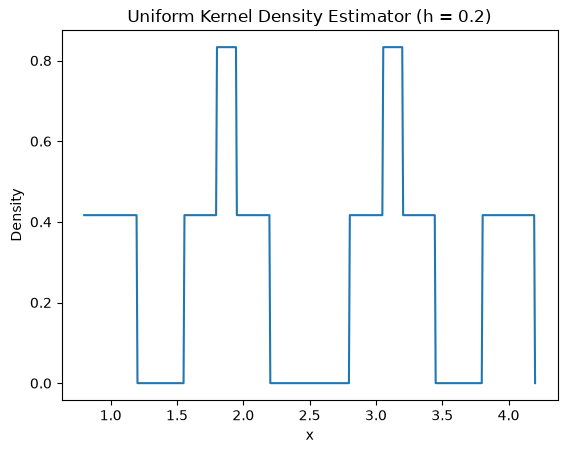

In [15]:
h = 0.2

# Create a range of x values
x_grid = np.linspace(min(data) - h, max(data) + h, 500)

# Calculate the uniform KDE
kde = np.zeros(len(x_grid))

for x in data:
    kde += (np.abs((x_grid - x) / h) <= 1) / (2 * len(data) * h)

# Plot the KDE
plt.plot(x_grid, kde)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Uniform Kernel Density Estimator (h = 0.2)")
plt.show()

**c. Compute the Silverman bandwidth for the uniform kernel using h = 1.84 * SD * n**(-0.2).
**

In [10]:
import statistics
h = 1.84 * statistics.stdev(data)* 6**(-0.2)
h


1.4231661885912126

**d. Sketch the uniform kernel density estimator for the Silverman bandwidth.**

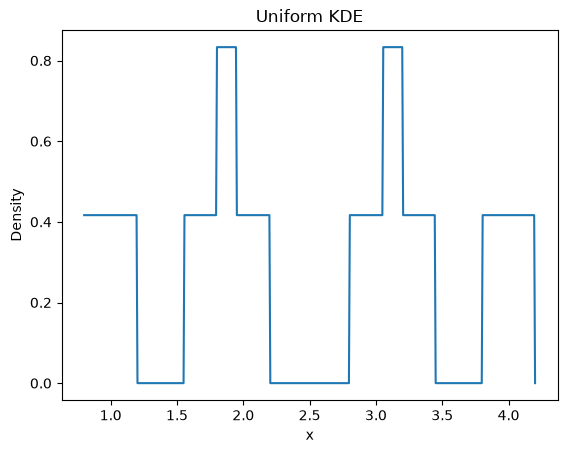

In [14]:
# x-values for the plot
x_grid = np.linspace(min(data) - h, max(data) + h, 500)

# Uniform KDE
kde = np.zeros(len(x_grid))

for xi in data:
    kde += (np.abs((x_grid - xi) / h) <= 1) / (2 * len(data) * h)

plt.plot(x_grid, kde)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Uniform KDE")
plt.show()

**e. How are b and d similar or different?**


b and d are similar because they are both uniform KDEs and have the same general step-like shape. However, they are different because they use different bandwidths. b has a bandwidth of 0.2, while d has a larger Silverman bandwidth of 1.423.



# Q2

**Using the uniform kernel with h = 0.6, compute the realized KDE at x = 0, f_hat_h(0), directly from these five numbers.**

In [36]:
X = [-1, -0.5, 0, 0.5, 1]
h = 0.6
x = 0

n = len(X)

kde = sum(np.abs(x - xi) <= h for xi in X) / (2 * n * h)

print(kde)

0.5


**Now compute E[f_hat_h(0)] at the same h = 0.6**

In [ ]:
from scipy.stats import norm

expected_kde = (norm.cdf(h) - norm.cdf(-h)) / (2 * h)
print(expected_kde)
#print(h)


0.3762448037498774
0.6


**c. Calculate the true density at `x=0`, using the Normal distribution.**

In [38]:
true_density = norm.pdf(0)
print(true_density)

0.3989422804014327


In [40]:
print(0.3762448037498774 - 0.3989422804014327)

-0.022697476651555304


**Are b and c equal? What does this mean about bias? (Keep in mind, truly proving anything about bias would require us to compare E[f_hat_h] to the Normal distribution for all x; calculating this at one point is only an indication of what is going on that you can extrapolate from.)**

No, b and c are not equal. The expected kde is less than the true density. It has a bias about −0.023. This shows the kde is biased at x = 0. 

**Recompute E[f_hat_h(0)] from (b) at a much smaller bandwidth, h = 0.1. What happens to the gap between E[f_hat_h(0)] and f(0) as h shrinks?**

In [43]:
h = 0.1

expected_kde_1 = (norm.cdf(h) - norm.cdf(-h)) / (2 * h)
print(expected_kde_1)
print(h)

0.3982783727702899
0.1


In [45]:
#bias
bias = expected_kde_1 - true_density
print(bias)

-0.0006639076311428238


As h shrinks, we see that the expected kde gets closer to the true density. It has a bias around -0.00066. The gap shrinks from about −0.023 (at h = 0.6) to about −0.00066 (at h = 0.1).

**Is f_hat_h a consistent estimator? Explain your reasoning.**

The kde is consistent if h goes to 0. The bandwidth gets smaller as we get more data, which reduces bias. Also, when there are enough observations in the window, it reduces variance. If h stays fixed, the bias does not go away. In this case, h = 0.6 the bias at x = 0 is about -0.023 regardless of n.

**What are the main considerations in choosing a bandwidth value h?**

The main consideration when choosing h is finding a balance between bias and variance. When h is small, it gives more detail but can make the kde noisy. When h is large, it gives a smoother curve but can hide important features in the data. The sample size also matters, since more data allows us to use a smaller bandwidth. 


# Q3

**a. Compute the uniform-kernel KDE, f_hat_h(x), at x = 6.0, x = 6.5, x = 7.0, x = 8.0, and x = 8.5.**

In [ ]:
X = [5, 7, 7, 8, 10]
h = 1.5

X = np.array([5, 7, 7, 8, 10])
h = 1.5
n = len(X)

x1 = 6.0
kde1 = np.sum(np.abs(x1 - X) <= h) / (n*2*h)
x2 = 6.5
kde2 = np.sum(np.abs(x2 - X) <= h) / (n*2*h)
x3 = 7.0
kde3 = np.sum(np.abs(x3 - X) <= h) / (n*2*h)
x4 = 8.0
kde4 = np.sum(np.abs(x4 - X) <= h) / (n*2*h)
x5 = 8.5
kde5 = np.sum(np.abs(x5 - X) <= h) / (n*2*h)

print(kde1, kde2, kde3, kde4, kde5)

0.2 0.26666666666666666 0.2 0.2 0.26666666666666666


**b. Compute the Gaussian-kernel KDE at the same five values of x, using the same h = 1.5**

In [ ]:
gauss = lambda z: np.exp( -z**2/2)/np.sqrt(2*np.pi) # Gaussian kernel

x1 = 6.0
kde1 = np.sum(gauss((x1 - X) / h)) / (n*h)
x2 = 6.5
kde2 = np.sum(gauss((x2 - X) / h)) / (n*h)
x3 = 7.0
kde3 = np.sum(gauss((x3 - X) / h)) /(n*h)
x4 = 8.0
kde4 = np.sum(gauss((x4 - X) / h)) / (n*h)
x5 = 8.5
kde5 = np.sum(gauss((x5 - X) / h)) / (n*h)

print(kde1, kde2, kde3, kde4, kde5)

0.15116667696891303 0.16865730580239766 0.17804448100191994 0.16744524435137584 0.1506023053792177


**Your part (a) values should jump abruptly between some of these five points, while your part (b) values should change smoothly. Identify where the biggest jump in (a) happens, and explain in terms of the two kernel shapes -- not just "one is smoother" -- why that jump exists in the uniform case but not the Gaussian case.**

The biggest jumps in part (a) is between all points: 6.0 and 6.5, 6.5 and 7.0 and between 8.0 and 8.5. Each jump is 0.0667. We have these jumps because the uniform kernel has a flat, rectangular shape. Observations within the bandwidth all have the same weight, so the KDE stays flat until an observation enters or leaves the bandwidth, causing a abrupt jump.However, the Gaussian kernel has a bell-shaped curve with no sharp cutoff, so the observations receive weights that gradually change with their distance from x. This makes the Gaussian KDE change smoothly instead of jumping abruptly.


**Why might you prefer one kernel over the other in practice?**

In practice, I might prefer the uniform kernel when I want a simple estimate where observations within a certain range have equal importance. I might prefer the Gaussian kernel when I want the weights to change gradually with distance and want a smoother estimate.


# Q4


In [5]:
df_heart = pd.read_csv("C:\\Users\\delee\\Documents\\DS5030_Fall26\\uu_kde\\data\\heart_failure_clinical_records_dataset.csv")
df_heart

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


**a. Plot a
kernel density estimate of ejection_fraction**

<Axes: xlabel='ejection_fraction', ylabel='Density'>

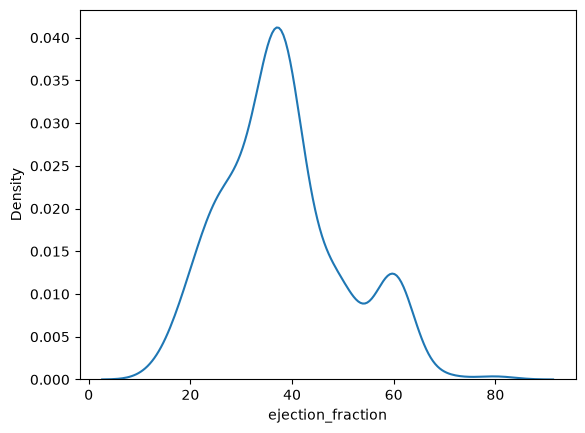

In [7]:
sns.kdeplot(data=df_heart["ejection_fraction"])

**Use Pandas' df.sample(frac=1.0, replace=True) to resample the data 15 times with replacement, plotting the kernel density estimtes for each sample.**

C:\Users\delee\AppData\Local\Temp\ipykernel_30936\1025802482.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


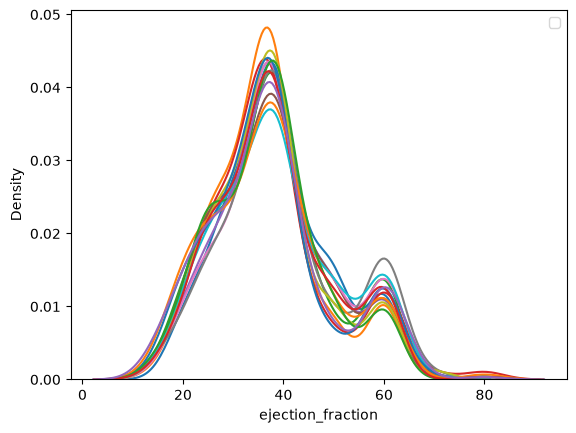

In [ ]:
import matplotlib.pyplot as plt

for i in range(15):
    sample = df_heart["ejection_fraction"].sample(frac=1.0, replace=True)
    sns.kdeplot(sample)

**For what values of ejection_fraction is the original plot reliable? For which values is there noticeable variation in your plots of the resampled data?**

The original plot is reliable for ejection_fraction values around 15–35 and 40–50, where the resampled KDE curves closely overlap. The main peak near 37 is also consistent in location, but its height varies across the resamples. There is more noticeable variation around the second bump near 60 and the small bump near 80. These areas should be interpreted more cautiously because the variation may be due to sampling noise.
